# Retail Sales Data Analysis

## Importing Required Libraries
| Library    | Purpose                          |
| ---------- | -------------------------------- |
| Pandas     | Data manipulation and analysis   |
| NumPy      | Numerical operations             |
| Seaborn    | Statistical visualizations       |
| Matplotlib | Plotting graphs                  |
| Warnings   | Suppressing unnecessary warnings |           |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

## Setting Visualization Styles
* `warnings.filterwarnings('ignore')` hides unnecessary warning messages.
* `plt.style.use()` applies a clean plotting style.
* `sns.set_palette()` changes default graph colors.

In [2]:
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


## Dataset Explore

### Loading the Dataset

* `pd.read_csv()` loads the CSV file into a DataFrame.
* `head(10)` displays the first 10 rows.

In [3]:
df = pd.read_csv('retail_sales.csv')
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


### Dataset Dimensions

* `shape[0]` → number of rows
* `shape[1]` → number of columns

In [4]:
print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset Dimensions: 1825 rows x 6 columns


### Checking Data Types

In [5]:
print(f"Columns and Data Types before conversion:\n{df.dtypes}")

Columns and Data Types before conversion:
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


### Optimized Data Loading

- `parse_dates=["Date"]` : Automatically converts the `Date` column into datetime format
- Using category type reduces memory usage significantly for repeated text values. Best for columns like:
  * Region
  * Category
  * Gender
  * Product Type

In [6]:
df = pd.read_csv(
    "retail_sales.csv",
    parse_dates=["Date"],
    dtype={
        "Category": "category",
        "Region": "category"
    }
)

### Creating Time-Based Features

| Feature   | Description      |
| --------- | ---------------- |
| Month     | Month number     |
| Quarter   | Business quarter |
| DayOfWeek | Weekday name     |
| MonthName | Full month name  |

- These features help in time-series and seasonal analysis.

In [7]:
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

### Date Range Analysis

In [8]:
print(f"Date Range:\n{df['Date'].min()} to {df['Date'].max()}")

Date Range:
2023-01-01 00:00:00 to 2023-12-31 00:00:00


### Numeric Conversion

- `pd.to_numeric()` : Converts columns into numeric format.
- `errors='coerce'` : Invalid values become `NaN`.

In [9]:
numeric_columns = ['Sales', 'Quantity', 'Profit']

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Converting Quantity into Nullable Integer

- `Int64` supports missing values while keeping integer format.

In [10]:
df['Quantity'] = df['Quantity'].astype('Int64')

### Checking Updated Data Types

In [11]:
print(f"Columns and Data Types after conversion:\n{df.dtypes}")

Columns and Data Types after conversion:
Date         datetime64[ns]
Category           category
Sales               float64
Quantity              Int64
Profit              float64
Region             category
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object


## Memory Usage Optimization

### Checking DataFrame Information

In [12]:
df.info()                            # Shows column types, null values, memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1825 non-null   datetime64[ns]
 1   Category   1821 non-null   category      
 2   Sales      1823 non-null   float64       
 3   Quantity   1820 non-null   Int64         
 4   Profit     1825 non-null   float64       
 5   Region     1820 non-null   category      
 6   Month      1825 non-null   int32         
 7   Quarter    1825 non-null   int32         
 8   DayOfWeek  1825 non-null   object        
 9   MonthName  1825 non-null   object        
dtypes: Int64(1), category(2), datetime64[ns](1), float64(2), int32(2), object(2)
memory usage: 105.8+ KB


### Checking Memory Usage

- Shows actual memory consumption of the column.

In [13]:
print(df['Region'].memory_usage(deep=True))

2395


## Handling Missing Values

### Missing Values

- Counts missing values in each column.

In [14]:
print(f"Missing Values\n{df.isnull().sum()}")

Missing Values
Date         0
Category     4
Sales        2
Quantity     5
Profit       0
Region       5
Month        0
Quarter      0
DayOfWeek    0
MonthName    0
dtype: int64


In [15]:
# Replace string representations of missing values with actual NaN
df.replace(['NaN', 'Nan', 'Null', 'NULL', 'null', 'NaN?'], np.nan, inplace=True)

### Filling Missing Values

`Mode`
Most frequent value in a column.
* Categorical data
* Discrete numeric data

`Median `
  - Middle value after sorting.
  - Median is preferred because it is less affected by outliers.

In [16]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mode()[0])

In [17]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

In [18]:
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

### Dropping Rows with Missing Region
Rows missing important information are removed.

In [19]:
df.dropna(subset=['Region'], inplace=True)

### Verifying Missing Values

In [20]:
df.isna().sum()

Date         0
Category     0
Sales        0
Quantity     0
Profit       0
Region       0
Month        0
Quarter      0
DayOfWeek    0
MonthName    0
dtype: int64

## Descriptive Statistics

In [21]:
print("Descriptive Statistics for Numerical Columns:\n")
df[['Sales', 'Quantity', 'Profit']].describe()

Descriptive Statistics for Numerical Columns:



,Sales,Quantity,Profit
count,1819.000000,1819.0,1819.000000
mean,980.603490,10.06652,248.298426
std,334.654759,5.513607,117.967782
min,0.000000,0.0,0.000000
25%,784.300020,5.0,156.773648
50%,997.725134,10.0,229.074934
75%,1207.899693,15.0,323.003670
max,1888.932537,19.0,703.228418


## Sorting Data

* Quantity → Descending
* Sales → Ascending

This helps identify:

* High quantity transactions
* Lower sales among high-volume purchases

In [22]:
df_sorted = df.sort_values(
    by=['Quantity', 'Sales'],
    ascending=[False, True]
)

df_sorted.head()

,Date,Category,Sales,Quantity,Profit,Region,Month,Quarter,DayOfWeek,MonthName
312,2023-03-04,Home Goods,0.000000,19,0.000000,West,3,1,Saturday,March
528,2023-04-16,Sports,0.000000,19,270.577388,West,4,2,Sunday,April
1708,2023-12-08,Sports,227.942727,19,61.534381,North,12,4,Friday,December
571,2023-04-25,Clothing,361.006937,19,57.285585,West,4,2,Tuesday,April
1213,2023-08-31,Sports,368.305917,19,73.419555,West,8,3,Thursday,August


## Ranking Sales

Sales are ranked within each Quantity group.

`method='dense'`

Ranks do not skip numbers.

| Sales | Rank |
| ----- | ---- |
| 500   | 1    |
| 500   | 1    |
| 300   | 2    |

In [23]:
df['Sales_rank'] = df.groupby('Quantity')['Sales'].rank(
    method='dense',     # No gaps in ranking
    ascending=False     # Highest sales get rank 1
)

## Data Visualization

### Monthly Sales Trend
Shows how sales change over time.

In [24]:
monthly_sales=df.groupby(['Month','MonthName']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum'
}).reset_index()

monthly_sales=monthly_sales.sort_values('Month')
monthly_sales

,Month,MonthName,Sales,Profit,Quantity
0,1,January,143366.447153,37495.835272,1499
1,2,February,132215.411776,34353.123612,1517
2,3,March,145321.200626,38584.599285,1447
3,4,April,138160.991209,37895.203187,1446
4,5,May,150774.977103,40527.689566,1603
5,6,June,152605.749860,39042.686605,1570
6,7,July,162111.115687,40208.956109,1536
7,8,August,148020.452251,34675.627875,1489
8,9,September,153094.700793,37796.761379,1598
9,10,October,151272.280840,36019.384158,1569


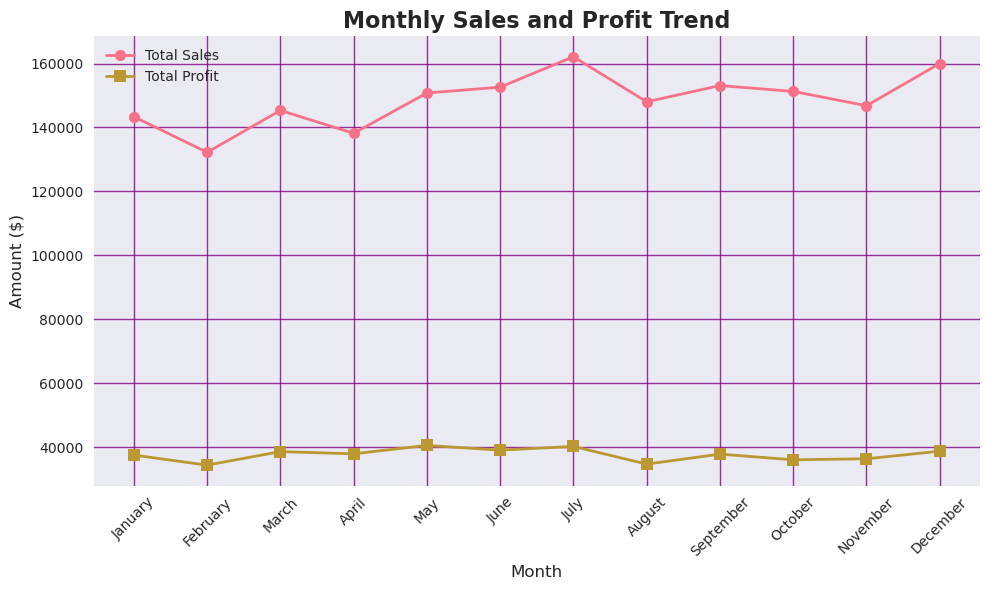

In [25]:
plt.figure(figsize=(10,6))
plt.plot(monthly_sales['MonthName'],monthly_sales['Sales'],marker='o',linewidth=2,markersize=8,label='Total Sales')
plt.plot(monthly_sales['MonthName'],monthly_sales['Profit'],marker='s',linewidth=2,markersize=8,label='Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize=16,fontweight='bold')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Amount ($)',fontsize=12)
plt.legend()
plt.grid(True,alpha=0.8,color="purple")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Monthly Sales and Profit Trend.png')
plt.show()

### Day of Week Analysis

In [26]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek']=pd.Categorical(df['DayOfWeek'],categories=day_order,ordered=True)
daily_performance=df.groupby('DayOfWeek').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean'
}).round(2)
daily_performance

,Sales,Profit,Quantity
DayOfWeek,,,
Monday,981.23,252.74,10.25
Tuesday,983.00,242.52,10.34
Wednesday,964.43,237.69,10.21
Thursday,966.83,237.62,9.78
Friday,1011.72,259.84,9.97
Saturday,975.95,252.59,9.68
Sunday,981.11,254.94,10.24


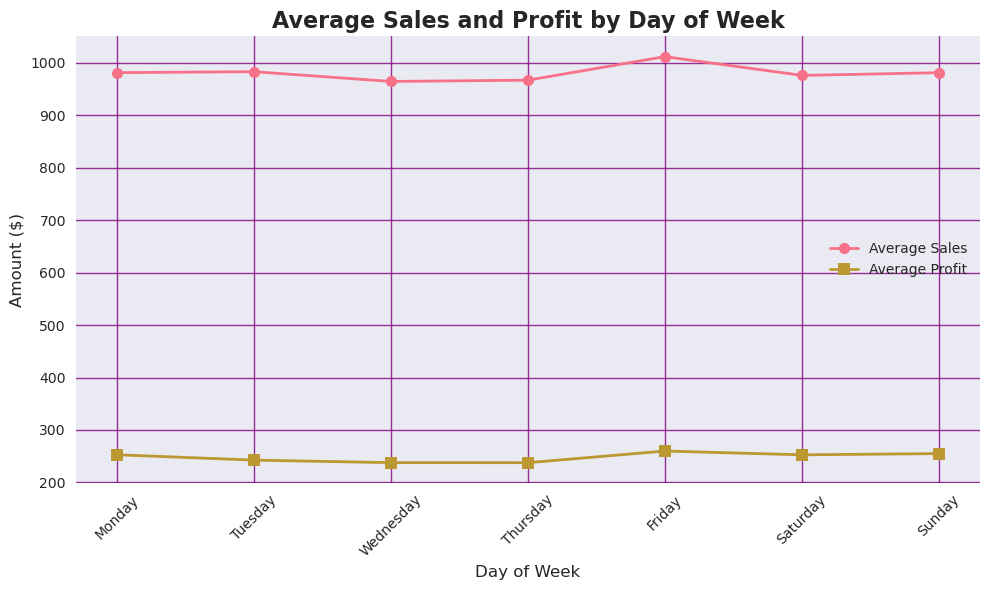

In [46]:
plt.figure(figsize=(10,6))
plt.plot(daily_performance.index,daily_performance['Sales'],marker='o',linewidth=2,markersize=8,label='Average Sales')
plt.plot(daily_performance.index,daily_performance['Profit'],marker='s',linewidth=2,markersize=8,label='Average Profit')
plt.title('Average Sales and Profit by Day of Week', fontsize=16,fontweight='bold')
plt.xlabel('Day of Week',fontsize=12)
plt.ylabel('Amount ($)',fontsize=12)
plt.legend()
plt.grid(True,alpha=0.8,color="purple")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Average Sales and Profit by Day of Week.png')
plt.show()

### Category-Wise Summary
Performs grouped aggregation for each category.

In [28]:
category_performance=df.groupby('Category').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum'
}).sort_values('Sales',ascending=False)
category_performance

,Sales,Profit,Quantity
Category,,,
Books,370971.872558,92304.452141,3737
Electronics,363371.420635,89894.080069,3587
Clothing,358178.751209,91613.246341,3697
Sports,346561.413563,90849.949134,3535
Home Goods,344634.290152,86993.108551,3755


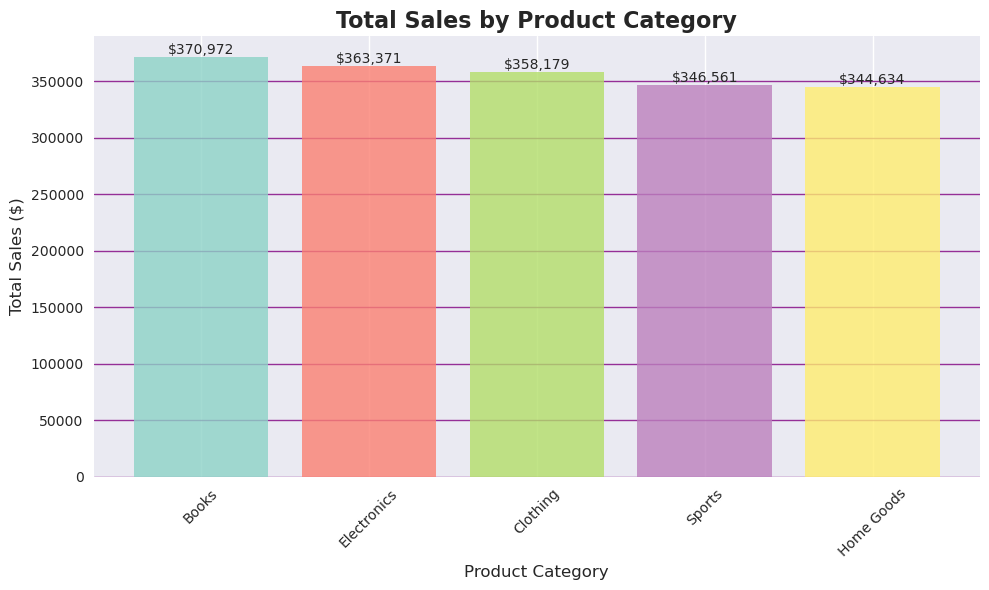

In [29]:
plt.figure(figsize=(10,6))

colors=plt.cm.Set3(np.linspace(0,1,len(category_performance)))
bars=plt.bar(category_performance.index,category_performance['Sales'],color=colors,alpha=0.8)

for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height,f'${height:,.0f}',ha='center',va='bottom')

plt.title('Total Sales by Product Category', fontsize=16,fontweight='bold')
plt.xlabel('Product Category',fontsize=12)
plt.ylabel('Total Sales ($)',fontsize=12)
plt.grid(axis='y',alpha=0.8,color="purple")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
regional_performance=df.groupby('Region').agg({
    'Sales': ['sum','mean','count'],
    'Profit':['sum','mean'],
}).round(2)
regional_performance

Sales                   Profit        
              sum    mean count        sum    mean
Region                                            
East    394439.34  991.05   398   98973.62  248.68
North   449292.76  976.72   460  112126.47  243.75
South   469471.28  969.98   484  118036.97  243.88
West    470514.37  986.40   477  122517.78  256.85

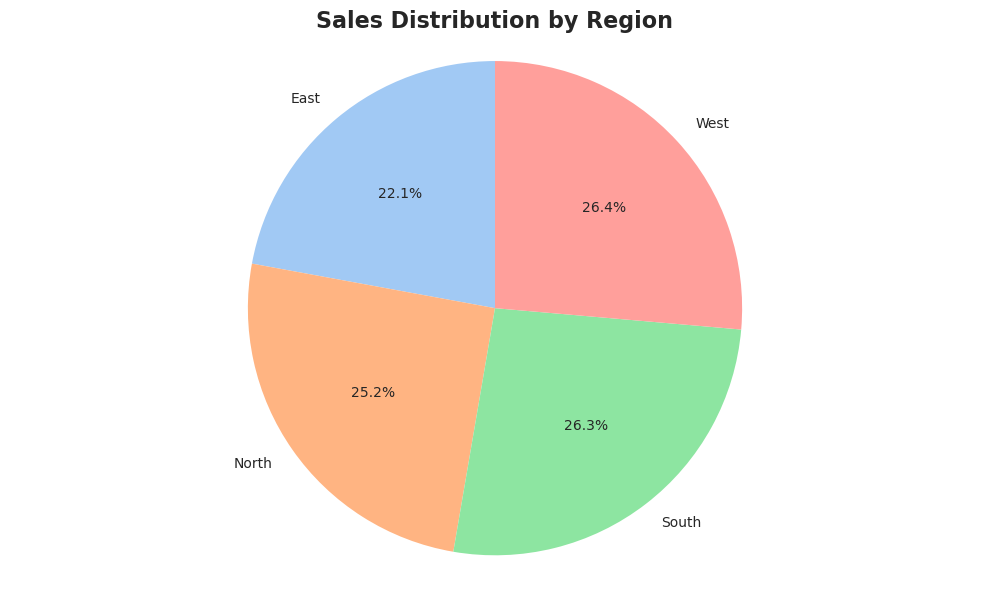

In [31]:
plt.figure(figsize=(10,6))

regional_data=df.groupby('Region')['Sales'].sum()
plt.pie(regional_data,labels=regional_data.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette("pastel"))

plt.title('Sales Distribution by Region', fontsize=16,fontweight='bold')
plt.axis('equal')
plt.savefig('Sales Distribution by Region.png')
plt.tight_layout()
plt.show()

### Correlation Heatmap
Displays relationships between numerical variables.

Correlation Values:

| Value | Meaning                      |
| ----- | ---------------------------- |
| +1    | Strong positive relationship |
| 0     | No relationship              |
| -1    | Strong negative relationship |
    

In [32]:
correlation_matrix = df[['Sales', 'Quantity', 'Profit']].corr()
correlation_matrix

,Sales,Quantity,Profit
Sales,1.000000,0.054893,0.530753
Quantity,0.054893,1.000000,0.028710
Profit,0.530753,0.028710,1.000000


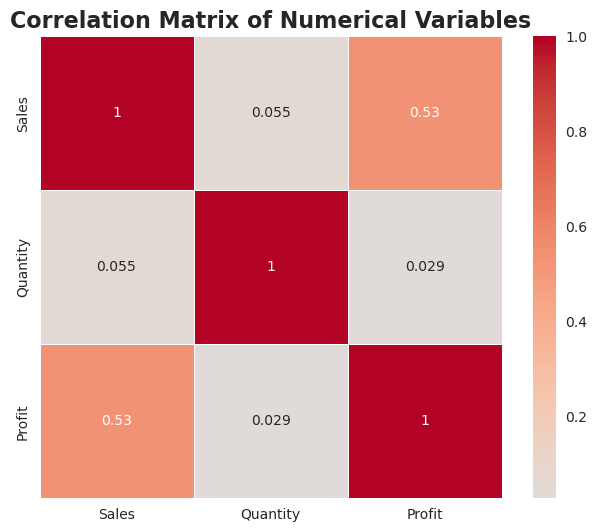

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',center=0,square=True,linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables',fontsize=16,fontweight='bold')
plt.savefig('correlation_heatmap.png')
plt.show()

## Final Dataset Information
Creates a smaller DataFrame for reporting and exporting.

In [34]:
clean_df = df[df["Sales"] > 0]  # Filtering Clean Data: Removes invalid or zero sales values.
clean_df

,Date,Category,Sales,Quantity,Profit,Region,Month,Quarter,DayOfWeek,MonthName,Sales_rank
0,2023-01-01,Electronics,1149.014246,11,383.664245,North,1,1,Sunday,January,29.0
1,2023-01-01,Clothing,958.520710,7,224.054049,East,1,1,Sunday,January,56.0
2,2023-01-01,Home Goods,1473.763845,2,466.593090,South,1,1,Sunday,January,7.0
3,2023-01-01,Sports,1230.230419,6,123.310460,West,1,1,Sunday,January,24.0
4,2023-01-01,Clothing,828.585950,12,88.591355,East,1,1,Sunday,January,67.0
...,...,...,...,...,...,...,...,...,...,...,...
1820,2023-12-31,Electronics,1132.749004,14,353.464221,West,12,4,Sunday,December,30.0
1821,2023-12-31,Clothing,679.261971,8,183.860200,North,12,4,Sunday,December,87.0
1822,2023-12-31,Home Goods,1193.733728,10,359.010938,South,12,4,Sunday,December,32.0
1823,2023-12-31,Sports,1076.118706,17,259.570916,North,12,4,Sunday,December,38.0


In [35]:
subset = clean_df[["Date", "Category", "Sales", "Region"]]
subset

,Date,Category,Sales,Region
0,2023-01-01,Electronics,1149.014246,North
1,2023-01-01,Clothing,958.520710,East
2,2023-01-01,Home Goods,1473.763845,South
3,2023-01-01,Sports,1230.230419,West
4,2023-01-01,Clothing,828.585950,East
...,...,...,...,...
1820,2023-12-31,Electronics,1132.749004,West
1821,2023-12-31,Clothing,679.261971,North
1822,2023-12-31,Home Goods,1193.733728,South
1823,2023-12-31,Sports,1076.118706,North


In [36]:
subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1776 entries, 0 to 1824
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1776 non-null   datetime64[ns]
 1   Category  1776 non-null   category      
 2   Sales     1776 non-null   float64       
 3   Region    1776 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(1)
memory usage: 45.5 KB


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1819 entries, 0 to 1824
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1819 non-null   datetime64[ns]
 1   Category    1819 non-null   category      
 2   Sales       1819 non-null   float64       
 3   Quantity    1819 non-null   Int64         
 4   Profit      1819 non-null   float64       
 5   Region      1819 non-null   category      
 6   Month       1819 non-null   int32         
 7   Quarter     1819 non-null   int32         
 8   DayOfWeek   1819 non-null   category      
 9   MonthName   1819 non-null   object        
 10  Sales_rank  1819 non-null   float64       
dtypes: Int64(1), category(3), datetime64[ns](1), float64(3), int32(2), object(1)
memory usage: 121.5+ KB


## Exporting Processed Data

### Export to Excel

In [38]:
subset.to_excel(
    "subset_sales.xlsx",
    sheet_name='sales',
    index=False
)

### Export to JSON

- JSON Parameters

| Parameter         | Meaning                  |
| ----------------- | ------------------------ |
| orient='records'  | List-like JSON format    |
| date_format='iso' | Standard ISO date format |

In [39]:
subset.to_json(
    "subset_sales.json",
    orient="records",
    date_format="iso"
)

## Analysis

In [40]:
print(f"Top Performing Category: {category_performance.index[0]}")
print(f"Best Performing Region: {regional_data.idxmax()}")
print(f"Highest Sales Month: {monthly_sales.loc[monthly_sales['Sales'].idxmax(),'MonthName']}")
print(f"Best Day of Week: {daily_performance['Sales'].idxmax()}")
print("Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("Total Annual Profit: ${:,.2f}".format(df['Profit'].sum()))

Top Performing Category: Books
Best Performing Region: West
Highest Sales Month: July
Best Day of Week: Friday
Total Annual Sales: $1,783,717.75
Total Annual Profit: $451,654.84


## Recommendations

In [41]:
print(f"Focus marketing efforts on {category_performance.index[0]} category.")
print("Investigate performance in lower-performaning regions.")
print(f"Plan promotions around {daily_performance['Sales'].idxmax()} to maximize sales.")
print("Allocate inventory based on monthly trend patterns.")
print("Monitor correlationbetween quantity and profit for pricing strategy.")

Focus marketing efforts on Books category.
Investigate performance in lower-performaning regions.
Plan promotions around Friday to maximize sales.
Allocate inventory based on monthly trend patterns.
Monitor correlationbetween quantity and profit for pricing strategy.


## Profitability Analysis

In [42]:
profit_margin=(df['Profit'].sum()/df['Sales'].sum())*100
print(f"Overall Profit Margin: {profit_margin:.2f} %")
print("\nProfit Margins by Category")
category_margins=(category_performance['Profit']/category_performance['Sales'])*100
for category,margin in category_margins.items():
    print(f"  {category}: {margin:.2f} %")

Overall Profit Margin: 25.32 %

Profit Margins by Category
  Books: 24.88 %
  Electronics: 24.74 %
  Clothing: 25.58 %
  Sports: 26.21 %
  Home Goods: 25.24 %
